In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import torch

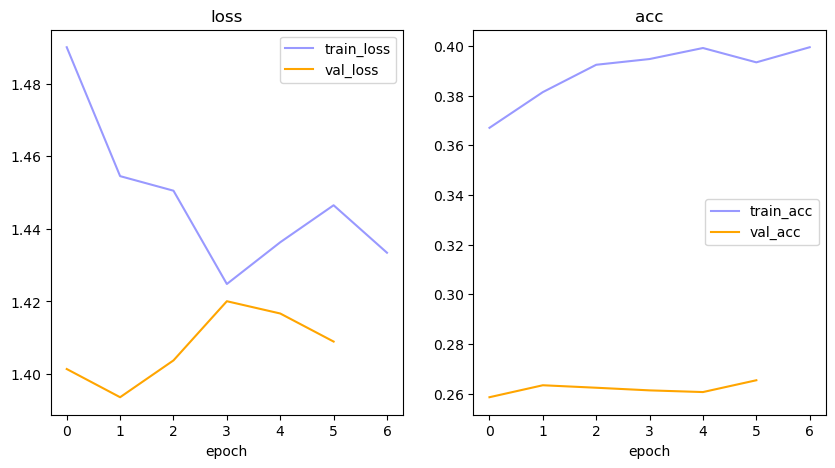

In [8]:
project_name = "BERT_Retrieval"
model_name = "BERT_WordEmbedding"
data_dir = f"Training_Progress/Logs/{project_name}/{model_name}"
subdir_name = "version_"
df = []
for i in os.listdir(data_dir):
    if i.startswith(subdir_name):
        df.append(pd.read_csv(f"{data_dir}/{i}/metrics.csv"))

metrics = pd.concat(df, axis = 0).groupby("epoch").mean()
# metrics.loc[:, "train_log"] = np.log(metrics.loc[:, "train_loss"])
# metrics.loc[:, "val_log"] = np.log(metrics.loc[:, "val_loss"])


plot_names = ["loss", "acc"]
fig = plt.figure(figsize =(5*len(plot_names), 5)) 
for i, kind in enumerate(plot_names):
    ax = fig.add_subplot(1, len(plot_names), i+1)
    metrics.loc[:, f"train_{kind}"].plot(ax = ax, color = "blue", label = f"train_{kind}", alpha = 0.4)
    metrics.loc[:, f"val_{kind}"].plot(ax = ax, color = "orange", label = f"val_{kind}")
    ax.legend()
    ax.set_title(kind)
    ax.get_yaxis().get_major_formatter().set_scientific(False)
    ax.get_yaxis().get_major_formatter().set_useOffset(False)
fig.suptitle("")
plt.show()